# ⚽ Глава 5 Юнит 2: Множественная регрессия и регуляризация
## Как предсказать рыночную стоимость футболиста?

> **Датасет:** Transfermarkt-style · 500 игроков · 7 признаков  
> **Уровень:** intermediate (после базовой линейной регрессии)  
> **Время:** ~90 минут

---

### 🎯 После этого урока ты сможешь:
- ✅ Понять, почему один признак — недостаточно, и как использовать несколько
- ✅ Реализовать множественную линейную регрессию через нормальное уравнение
- ✅ Объяснить, что такое переобучение, и увидеть его на графике
- ✅ Применить Ridge и Lasso регуляризацию, написав их с нуля
- ✅ Выбрать гиперпараметр `alpha` честным способом — через кросс-валидацию
- ✅ Интерпретировать веса модели в контексте трансферного рынка

---

### 🌍 Зачем это нужно в реальной жизни?

Transfermarkt оценивает стоимость каждого из 700 000+ футболистов на планете.  
FIFA использует похожие модели для рейтинга игроков в видеоигре.  
Реальные клубы — **Ман Сити, Байерн, Реал Мадрид** — используют аналитику  
для принятия решений о трансферах стоимостью 50–200 миллионов евро.

**Вопрос:** Откуда берётся цифра «100 млн евро» за Эрлинга Холанда?  
**Ответ:** Из регрессионных моделей — таких, как та, что ты построишь сегодня.


---

## 📖 Концепция 1: От одного признака к нескольким

### Чего не хватало в прошлом уроке?

В прошлый раз мы предсказывали стоимость игрока **по одному признаку** —  
например, по количеству голов. Это давало грубую оценку, но упускало много деталей.

Рассмотрим двух игроков, оба забивают **0.4 гола за игру:**
- Игрок А: 22 года, играет в Премьер-лиге, рейтинг FIFA = 85  
- Игрок Б: 34 года, играет в третьей лиге Испании, рейтинг FIFA = 71

По числу голов они одинаковы. Но их рыночная стоимость может отличаться  
**в 20–50 раз!** Модель с одним признаком этого никогда не поймёт.

### Идея множественной регрессии

Мы хотим учесть **все** факторы одновременно:

```
Стоимость ≈ w₀ + w₁·возраст + w₂·голы + w₃·ассисты + w₄·рейтинг + ...
```

Каждый признак получает свой **вес** (`w`), который говорит:  
*«насколько сильно этот фактор влияет на стоимость?»*

Задача обучения — найти оптимальные веса так, чтобы наши предсказания  
были максимально близки к реальным ценам.

> **Аналогия:** Это как оценка квартиры — риелтор смотрит одновременно  
> на площадь, этаж, район, состояние ремонта, год постройки.  
> Каждый фактор вносит свой вклад. Регрессия — это просто  
> математический риелтор.


## 📦 Шаг 0: Импорты (просто запусти)

In [1]:
import json
import importlib.util

import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, Lasso, LinearRegression

np.random.seed(42)
plt.rcParams['figure.figsize'] = (11, 5)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.unicode_minus'] = False
print('✅ Все библиотеки загружены!')


def emit_checkpoint(checkpoint_id, **metrics):
    payload = {k: float(v) if isinstance(v, (np.floating, float, int)) else v for k, v in metrics.items()}
    print(f"CHECKPOINT:{checkpoint_id}:{json.dumps(payload, sort_keys=True)}")


✅ Все библиотеки загружены!


---

## 🏟️ Шаг 1: Наш датасет — 500 футболистов Transfermarkt

### Что означает каждый признак?

Прежде чем запускать код — разберём, откуда берутся наши данные и что они значат.

| Признак | Что это | Типичные значения |
|---------|---------|------------------|
| `age` | Возраст игрока | 18–35 лет |
| `goals_per_game` | Голы за игру | 0.0–0.8 (форварды ~0.4) |
| `assists_per_game` | Ассисты за игру | 0.0–0.5 |
| `overall_rating` | Рейтинг FIFA | 50–99 (Холанд ≈ 91) |
| `league_level` | Уровень лиги | **1 = топ** (АПЛ), 5 = низшая |
| `years_in_pro` | Лет в профессионале | 1–18 |
| `is_striker` | Форвард (1) или нет (0) | 0 или 1 |

> ⚠️ **Важно про `league_level`:** Цифра `1` означает **лучшую** лигу!  
> Это значит: высокий `league_level` = хуже лига = меньше стоимость.  
> Поэтому вес у этого признака будет **отрицательным** — не пугайся, это правильно!

### Как формируется стоимость?

В реальном Transfermarkt стоимость — экспертная оценка скаутов.  
Мы **симулируем** её по формуле с реалистичными весами плюс случайный шум:

```
Стоимость = -1.2·(возраст-26)² + 40·голы + 25·ассисты + 0.8·(рейтинг-70)
            - 4·уровень_лиги + 1.5·опыт + 5·форвард + шум
```

Заметь: `(возраст-26)²` — это **нелинейный** признак! Пик стоимости в 26 лет,  
до и после — снижение. Наша линейная модель этого не увидит (пока).


In [2]:
def generate_fifa_dataset(n_players=500, seed=42):
    """Генерирует синтетический датасет FIFA/Transfermarkt."""
    rng = np.random.default_rng(seed)

    age            = rng.integers(18, 36, n_players).astype(float)
    goals_per_game = rng.beta(2, 5, n_players)
    assists_per_g  = rng.beta(1.5, 6, n_players)
    overall_rating = rng.normal(72, 8, n_players).clip(50, 99)
    league_level   = rng.integers(1, 6, n_players).astype(float)
    years_in_pro   = (age - 17 + rng.normal(0, 1, n_players)).clip(1, 18)
    is_striker     = (rng.random(n_players) < 0.25).astype(float)

    market_value = (
        -1.2 * (age - 26)**2
        + 40  * goals_per_game
        + 25  * assists_per_g
        + 0.8 * (overall_rating - 70)
        - 4   * league_level
        + 1.5 * years_in_pro
        + 5   * is_striker
        + rng.normal(0, 3, n_players)
    ).clip(1, 120)

    feature_names = [
        'age', 'goals_per_game', 'assists_per_game',
        'overall_rating', 'league_level', 'years_in_pro', 'is_striker'
    ]
    X = np.column_stack([
        age, goals_per_game, assists_per_g,
        overall_rating, league_level, years_in_pro, is_striker
    ])
    return X, market_value, feature_names

X, y, feature_names = generate_fifa_dataset()
n_samples, n_features = X.shape

print(f'Датасет: {n_samples} игроков, {n_features} признаков')
print(f'Признаки: {feature_names}')
print(f'Стоимость (млн €): мин={y.min():.1f}  макс={y.max():.1f}  среднее={y.mean():.1f}')
emit_checkpoint('dataset_shape', n_samples=n_samples, n_features=n_features, y_mean=y.mean())


Датасет: 500 игроков, 7 признаков
Признаки: ['age', 'goals_per_game', 'assists_per_game', 'overall_rating', 'league_level', 'years_in_pro', 'is_striker']
Стоимость (млн €): мин=1.0  макс=49.3  среднее=7.9
CHECKPOINT:dataset_shape:{"n_features": 7.0, "n_samples": 500.0, "y_mean": 7.949382634048435}


#### Checkpoint-ориентир
Ожидаемый диапазон для `synthetic`: `n_samples=500`, `n_features=7`, `y_mean` примерно `1..25`.


### 🔍 Разведочный анализ: смотрим на данные перед моделированием

**Правило ML:** Никогда не строй модель не посмотрев на данные.  
Это помогает найти ошибки, выбросы, понять распределения.

Запусти следующую ячейку и ответь на вопросы после неё:


C:\Users\Admin\AppData\Local\Temp\ipykernel_18340\1465793998.py:24: UserWarning: Glyph 9917 (\N{SOCCER BALL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\Admin\Projects\PythonProjects\hackathon\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9917 (\N{SOCCER BALL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


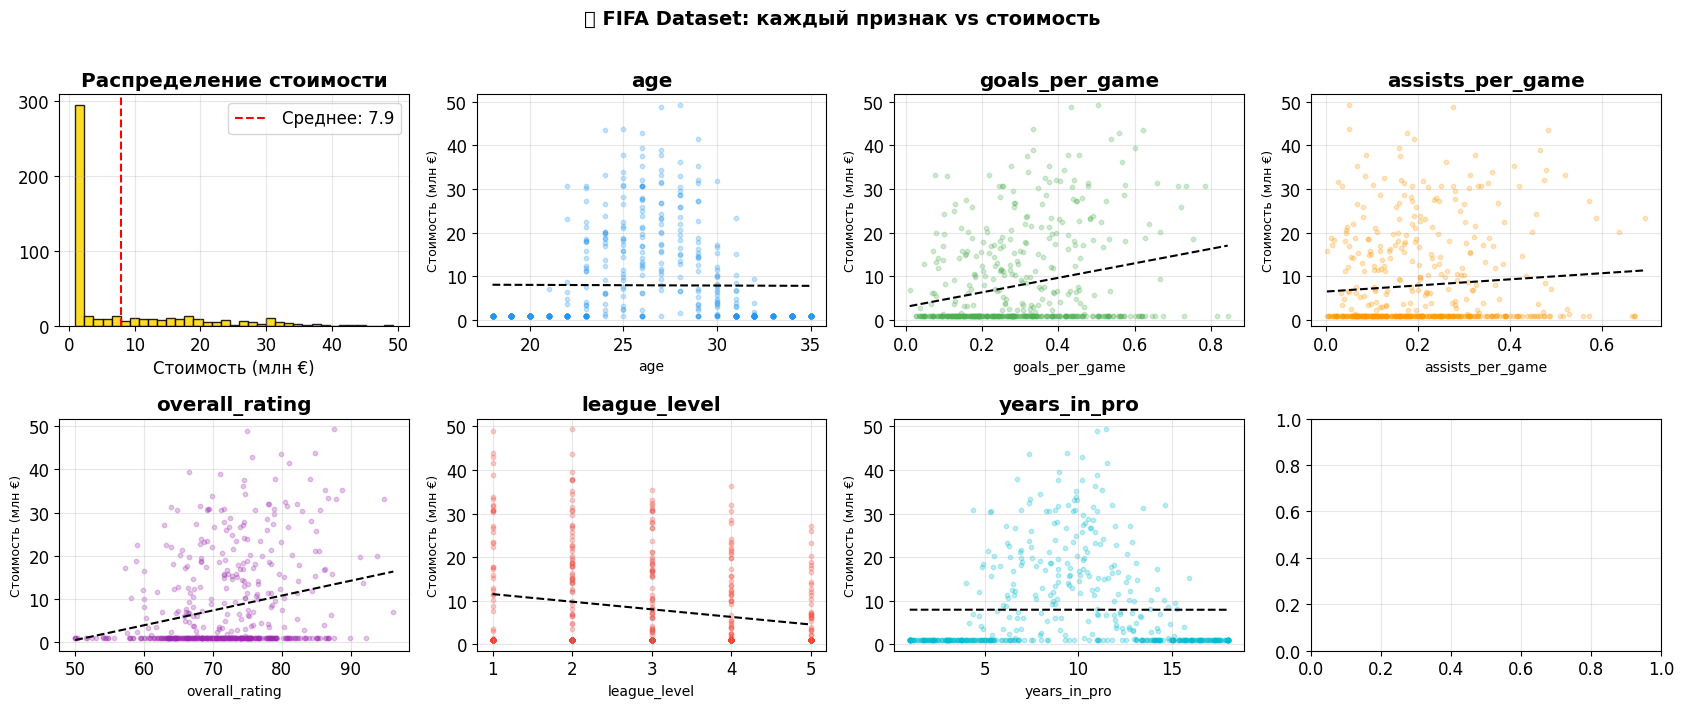


📊 Корреляция каждого признака со стоимостью:
  (положительная = больше значение → дороже игрок)

  age                    –                           r = -0.007
  goals_per_game         +██████                     r = +0.249
  assists_per_game       +██                         r = +0.087
  overall_rating         +██████                     r = +0.256
  league_level           –█████                      r = -0.222
  years_in_pro           –                           r = -0.000
  is_striker             +███                        r = +0.121


In [3]:
fig, axes = plt.subplots(2, 4, figsize=(17, 7))
axes = axes.flatten()

# Распределение целевой переменной
axes[0].hist(y, bins=35, color='gold', edgecolor='black', alpha=0.85)
axes[0].set_title('Распределение стоимости', fontweight='bold')
axes[0].set_xlabel('Стоимость (млн €)')
axes[0].axvline(y.mean(), color='red', linestyle='--', label=f'Среднее: {y.mean():.1f}')
axes[0].legend()

colors = ['#2196F3','#4CAF50','#FF9800','#9C27B0','#F44336','#00BCD4']
for i, (name, color) in enumerate(zip(feature_names, colors)):
    axes[i+1].scatter(X[:, i], y, alpha=0.25, s=10, color=color)
    # Линия тренда
    z = np.polyfit(X[:, i], y, 1)
    p = np.poly1d(z)
    xs = np.linspace(X[:, i].min(), X[:, i].max(), 100)
    axes[i+1].plot(xs, p(xs), 'k--', lw=1.5)
    axes[i+1].set_xlabel(name, fontsize=10)
    axes[i+1].set_ylabel('Стоимость (млн €)', fontsize=9)
    axes[i+1].set_title(f'{name}', fontweight='bold')

plt.suptitle('⚽ FIFA Dataset: каждый признак vs стоимость', y=1.01, fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('\n📊 Корреляция каждого признака со стоимостью:')
print('  (положительная = больше значение → дороже игрок)')
print()
for i, name in enumerate(feature_names):
    corr = np.corrcoef(X[:, i], y)[0, 1]
    bar = '█' * int(abs(corr) * 25)
    sign = '+' if corr > 0 else '–'
    print(f'  {name:22s} {sign}{bar:<25}  r = {corr:+.3f}')


### 📝 TODO 1 — Разведочный анализ

Посмотри на графики и таблицу корреляций. Здесь тебе нужно проанализировать данные и записать выводы в ячейке ниже:

1. Какой признак **сильнее всего** коррелирует со стоимостью?  
   Это соответствует твоей интуиции о футболе?

2. У `league_level` **отрицательная** корреляция со стоимостью.  
   Объясни **своими словами** — почему это логично, если 1 = топ-лига?

3. Распределение стоимости — симметричное или скошенное?  
   Что это говорит нам о «типичном» футболисте в нашей выборке?

4. [OPTIONAL] Признак `age` — что ты видишь на его графике?  
   Почему линия тренда здесь может вводить в заблуждение?


**✏️ Твои ответы:**

1. Сильнее всего коррелирует: `количество голов и общий рейтинг`  
   Это логично, потому что: `тем кто забивает лучше платят`

2. Отрицательная корреляция `league_level` объясняется тем, что: `первая лига имеет самых профессиональных футболистов`

3. Распределение выглядит как линия, это значит: корреляция линейная

4. [OPTIONAL] По `age` я вижу: `большинство прибыльных футболистов находится в диапазоне 23-30 лет`


---

## ✂️ Шаг 2: Разделение данных и масштабирование

### Почему мы делим данные на train и test?

Представь такую ситуацию: учитель математики говорит:  
*«Завтра экзамен. Вот 100 задач для подготовки.»*  
На самом экзамене — ровно те же 100 задач с теми же числами.  
Ты получишь 100/100, но **ничего не выучишь**.

С ML — та же проблема. Если оценивать модель на тех же данных,  
на которых она обучалась — получим **оптимистичную, но ложную** оценку.

**Правило:** 80% данных — тренировка (учебник), 20% — тест (экзамен).  
Тестовые данные модель видит **ровно один раз** — в конце.

---

### Почему нужно масштабировать признаки?

Посмотри на диапазоны наших признаков:
- `age`: от 18 до 35 (диапазон ≈ 17)  
- `overall_rating`: от 50 до 99 (диапазон ≈ 49)  
- `goals_per_game`: от 0 до 0.8 (диапазон ≈ 0.8)  

Когда мы применим **регуляризацию** (позже), штраф за «большой вес»  
будет несправедлив: чтобы признак `goals_per_game` (маленький диапазон)  
сильно влиял на результат, у него должен быть **огромный вес** →  
регуляризация накажет его сильнее, чем `age`.

**`StandardScaler`** решает это: приводит каждый признак к `среднее=0, std=1`.  
После этого «единица» означает одно и то же для всех признаков.

---

### ⚠️ Критическая ошибка, которую совершают все

```python
# ❌ НЕПРАВИЛЬНО — data leakage!
scaler.fit(X)           # обучаем scaler на ВСЕХ данных (включая test)
X_scaled = scaler.transform(X)
X_train, X_test = train_test_split(X_scaled, ...)  # информация о test уже внутри!

# ✅ ПРАВИЛЬНО — scaler видит только train
X_train, X_test = train_test_split(X, ...)
scaler.fit(X_train)                      # обучаем только на train
X_train_scaled = scaler.transform(X_train)
X_test_scaled  = scaler.transform(X_test)   # применяем те же параметры к test
```

Почему первый вариант плохой? Потому что `scaler.fit` запоминает  
среднее и std **всего датасета**, включая тест.  
Это значит, что наша модель косвенно «видела» тестовые данные при подготовке.  
Оценка качества становится завышенной.


In [4]:
# ──────────────────────────────────────────────────────────────────────────────
# ПРАВИЛО №1: Сначала split, ПОТОМ scale!
# Если сначала scale → информация о тестовых данных 'утекает' в модель
# ──────────────────────────────────────────────────────────────────────────────

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f'Train: {X_train.shape[0]} игроков | Test: {X_test.shape[0]} игроков')

# StandardScaler: mean=0, std=1 для каждого признака
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit + transform на train
X_test_scaled  = scaler.transform(X_test)         # только transform на test!

print(f'\nПосле масштабирования (train):')
print(f'  Среднее по признакам: {X_train_scaled.mean(axis=0).round(2)}')
print(f'  Std по признакам:    {X_train_scaled.std(axis=0).round(2)}')

# Добавляем единичный столбец для bias-терма (свободного члена)
def add_bias(X):
    """Добавляет столбец единиц слева для w₀ (bias/intercept)."""
    return np.hstack([np.ones((X.shape[0], 1)), X])

X_train_b = add_bias(X_train_scaled)
X_test_b  = add_bias(X_test_scaled)
print(f'\nФорма X_train_b: {X_train_b.shape}  ← первый столбец = единицы (для bias)')


Train: 400 игроков | Test: 100 игроков

После масштабирования (train):
  Среднее по признакам: [-0. -0. -0.  0.  0. -0.  0.]
  Std по признакам:    [1. 1. 1. 1. 1. 1. 1.]

Форма X_train_b: (400, 8)  ← первый столбец = единицы (для bias)


### 🎛️ Мини-лаборатория: подгоняем вес и bias вручную

Попробуй руками менять коэффициент `w` и `b` для одного признака (`overall_rating`):
- увидишь, как изменяются MSE/RMSE и регуляризационные штрафы L1/L2;
- формула `y_hat = w * x + b` обновляется динамически;
- это помогает почувствовать, что именно оптимизирует модель;
- справа динамически обновляется график L1/L2 потерь при движении ползунков.


In [ ]:
if importlib.util.find_spec('ipywidgets') is None:
    print("⚠️ Для интерактива установи ipywidgets: pip install ipywidgets")
else:
    import ipywidgets as widgets
    from IPython.display import display

    x_manual = X_train_scaled[:, feature_names.index('overall_rating')]
    y_manual = y_train

    def _manual_metrics(weight, bias):
        y_hat = weight * x_manual + bias
        residuals = y_manual - y_hat
        mse = np.mean(residuals ** 2)
        rmse = np.sqrt(mse)
        l1 = np.mean(np.abs(residuals))
        l2 = np.mean(residuals ** 2)
        return y_hat, mse, rmse, l1, l2

    w_slider = widgets.FloatSlider(value=0.0, min=-12.0, max=12.0, step=0.1, description='Weight')
    b_slider = widgets.FloatSlider(value=float(np.mean(y_manual)), min=0.0, max=max(30.0, float(np.max(y_manual) + 5)), step=0.1, description='Bias')

    def _render(weight, bias):
        y_hat, mse, rmse, l1, l2 = _manual_metrics(weight, bias)

        fig, axes = plt.subplots(1, 2, figsize=(14, 4.5), gridspec_kw={'width_ratios': [3, 1.4]})
        axes[0].scatter(x_manual, y_manual, alpha=0.45, color='#5A8DEE', s=25)
        order = np.argsort(x_manual)
        axes[0].plot(x_manual[order], y_hat[order], color='#3F72AF', lw=2.5)
        for xi, yi, pi in zip(x_manual[::8], y_manual[::8], y_hat[::8]):
            axes[0].plot([xi, xi], [yi, pi], color='#F08A24', alpha=0.55)
        axes[0].set_title('Реальные точки и твоя прямая')
        axes[0].set_xlabel('overall_rating (scaled)')
        axes[0].set_ylabel('market_value (млн €)')

        metric_names = ['L1 (MAE)', 'L2 (MSE)']
        metric_values = [l1, l2]
        metric_colors = ['#26A69A', '#EF5350']
        axes[1].bar(metric_names, metric_values, color=metric_colors, alpha=0.85)
        axes[1].set_title('Потери при текущих w и b')
        axes[1].set_ylabel('Значение loss')
        axes[1].text(0.02, 0.97, f"y_hat = {weight:+.2f} * x + {bias:+.2f}", transform=axes[1].transAxes, va='top', fontsize=11)
        axes[1].text(0.02, 0.84, f"RMSE: {rmse:.3f}", transform=axes[1].transAxes, va='top', fontsize=11)

        plt.tight_layout()
        plt.show()

    ui = widgets.interactive_output(_render, {'weight': w_slider, 'bias': b_slider})
    display(widgets.HBox([w_slider, b_slider]))
    display(ui)


Output()

---

## 🧮 Шаг 3: Нормальное уравнение — аналитическое решение

### Математика, объяснённая по-человечески

**Задача:** Найти веса $\mathbf{w} = [w_0, w_1, ..., w_7]$ такие, что  
предсказание $\hat{y} = \mathbf{X}\mathbf{w}$ максимально близко к реальным ценам $\mathbf{y}$.

**Что мы минимизируем:**
$$\text{MSE}(\mathbf{w}) = \frac{1}{n}\|\mathbf{X}\mathbf{w} - \mathbf{y}\|^2$$

**Почему есть аналитическое решение?**  
MSE — это «чаша» (выпуклая квадратичная функция) без локальных минимумов.  
У такой функции есть ровно **один** минимум, и мы можем найти его точно,  
взяв производную и приравняв к нулю.

**Вывод:**

$$\frac{\partial \text{MSE}}{\partial \mathbf{w}} = \frac{2}{n}\mathbf{X}^\top(\mathbf{X}\mathbf{w} - \mathbf{y}) = 0$$

$$\mathbf{X}^\top\mathbf{X}\mathbf{w} = \mathbf{X}^\top\mathbf{y}$$

$$\boxed{\mathbf{w}^* = (\mathbf{X}^\top\mathbf{X})^{-1}\mathbf{X}^\top\mathbf{y}}$$

**Геометрический смысл:**  
Каждый игрок — точка в 7-мерном пространстве.  
Мы ищем гиперплоскость (обобщение прямой на много измерений),  
которая проходит «ближе всего» ко всем 500 точкам одновременно.  
Нормальное уравнение даёт нам эту плоскость **мгновенно, без итераций**.

**Почему `np.linalg.solve` лучше `np.linalg.inv`?**  
`inv(A) @ b` — явно обращает матрицу (медленно и нестабильно при плохой матрице).  
`solve(A, b)` — решает систему $A\mathbf{x}=\mathbf{b}$ через LU-разложение  
(быстрее на ~3× и численно стабильнее).


In [6]:
def fit_linear_regression(X, y):
    """
    Обучить множественную линейную регрессию через нормальное уравнение.
    """
    # TODO_ID:linear_normal_equation:start
    XtX = X.T @ X
    Xty = X.T @ y
    w   = np.linalg.inv(XtX) @ Xty
    # TODO_ID:linear_normal_equation:end
    return w

<details>
<summary>💡 Подсказка 1 — направление</summary>

Нормальное уравнение — это три операции:  
транспонирование (`X.T`), матричное умножение (`@`), решение системы.  
Попробуй написать по одной строке на каждый шаг.
</details>

<details>
<summary>💡 Подсказка 2 — конкретнее</summary>

```python
XtX = X.T @ X        # матрица (p+1) × (p+1)
Xty = X.T @ y        # вектор  (p+1,)
```
Теперь нужно решить систему `XtX · w = Xty`.
</details>

<details>
<summary>💡 Подсказка 3 — почти решение</summary>

```python
XtX = X.T @ X
Xty = X.T @ y
w   = np.linalg.solve(XtX, Xty)
```
Проверь: `w.shape` должно быть `(8,)` — 7 признаков + 1 bias.
</details>


In [7]:
# ──── Тест твоей реализации ──────────────────────────────────────────────────
w_linear = fit_linear_regression(X_train_b, y_train)

assert w_linear is not None and not isinstance(w_linear, type(...)), \
    "Ты забыл заполнить TODO — w всё ещё '...'"
assert w_linear.shape == (X_train_b.shape[1],), \
    f"Ожидали форму ({X_train_b.shape[1]},), получили {w_linear.shape}"

preds_check = X_train_b @ w_linear
mse_check = np.mean((preds_check - y_train)**2)
assert mse_check < 100, f"Train MSE={mse_check:.1f} — слишком большой, проверь формулу!"

print(f"✅ Тест пройден! Train MSE = {mse_check:.2f}")
print(f"\nВеса модели:")
print(f"  Bias (w₀):  {w_linear[0]:+.3f} млн €")
for name, w in zip(feature_names, w_linear[1:]):
    print(f"  {name:22s}: {w:+.4f}")


✅ Тест пройден! Train MSE = 97.57

Веса модели:
  Bias (w₀):  +8.500 млн €
  age                   : -3.3950
  goals_per_game        : +2.7966
  assists_per_game      : +1.1357
  overall_rating        : +2.9827
  league_level          : -2.6291
  years_in_pro          : +3.1866
  is_striker            : +1.6612


### 🔍 Интерпретация весов

После обучения смотрим на веса. Они показывают:  
*«при изменении признака на 1 стандартное отклонение, стоимость меняется на W млн €»*

> Заметь: веса сопоставимы друг с другом **только потому, что мы стандартизировали**  
> признаки. Без этого вес `age` (диапазон 17) и `goals_per_game` (диапазон 0.8)  
> нельзя было бы сравнивать.


📊 Линейная регрессия (без регуляризации):
  Train RMSE: 9.88 млн €  |  Train R²: 0.216
  Test  RMSE: 8.30 млн €  |  Test  R²: 0.058

  Интерпретация RMSE: в среднем модель ошибается на ±8.3 млн €
  R²=0.06 означает: модель объясняет 6% вариации стоимости


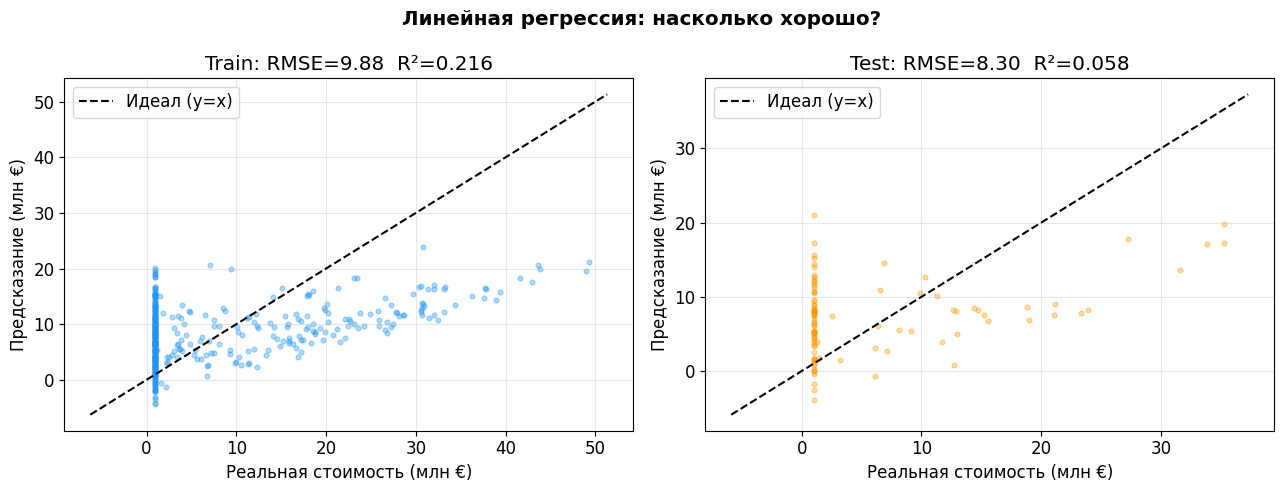

CHECKPOINT:linear_metrics:{"test_r2": 0.05806596750171544, "test_rmse": 8.296752288521612, "train_r2": 0.2162085706384126, "train_rmse": 9.877773471008053}
Ожидаемая зона: test_rmse≈2..12, test_r2≈0.3..1.0


In [8]:
# Реализуем функции оценки качества
def compute_mse(y_true, y_pred):
    """MSE = среднее квадратичное отклонение. Единицы: (млн €)²."""
    return np.mean((y_true - y_pred) ** 2)

def compute_rmse(y_true, y_pred):
    """RMSE = √MSE. Единицы те же что у y (млн €) — удобнее для интерпретации."""
    return np.sqrt(compute_mse(y_true, y_pred))

def compute_r2(y_true, y_pred):
    """
    R² ∈ (-∞, 1]:
      R²=1: идеальная модель
      R²=0: модель = среднее (бесполезна)
      R²<0: хуже среднего
    """
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - y_true.mean()) ** 2)
    return 1 - ss_res / ss_tot

# ──── Оцениваем качество ─────────────────────────────────────────────────────
y_train_pred = X_train_b @ w_linear
y_test_pred  = X_test_b  @ w_linear

train_rmse = compute_rmse(y_train, y_train_pred)
test_rmse  = compute_rmse(y_test,  y_test_pred)
train_r2   = compute_r2(y_train, y_train_pred)
test_r2    = compute_r2(y_test,  y_test_pred)

print("📊 Линейная регрессия (без регуляризации):")
print(f"  Train RMSE: {train_rmse:.2f} млн €  |  Train R²: {train_r2:.3f}")
print(f"  Test  RMSE: {test_rmse:.2f} млн €  |  Test  R²: {test_r2:.3f}")
print()
print(f"  Интерпретация RMSE: в среднем модель ошибается на ±{test_rmse:.1f} млн €")
print(f"  R²={test_r2:.2f} означает: модель объясняет {test_r2*100:.0f}% вариации стоимости")

# Визуализация: предсказание vs реальность
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, (y_true, y_pred, label, color) in zip(axes, [
    (y_train, y_train_pred, 'Train', '#2196F3'),
    (y_test,  y_test_pred,  'Test',  '#FF9800'),
]):
    ax.scatter(y_true, y_pred, alpha=0.35, s=12, color=color)
    lims = [min(y_true.min(), y_pred.min())-2, max(y_true.max(), y_pred.max())+2]
    ax.plot(lims, lims, 'k--', lw=1.5, label='Идеал (y=x)')
    ax.set_xlabel('Реальная стоимость (млн €)')
    ax.set_ylabel('Предсказание (млн €)')
    ax.set_title(f'{label}: RMSE={compute_rmse(y_true, y_pred):.2f}  R²={compute_r2(y_true, y_pred):.3f}')
    ax.legend()
plt.suptitle('Линейная регрессия: насколько хорошо?', fontweight='bold')
plt.tight_layout()
plt.show()

emit_checkpoint('linear_metrics', train_rmse=train_rmse, test_rmse=test_rmse, train_r2=train_r2, test_r2=test_r2)
print('Ожидаемая зона: test_rmse≈2..12, test_r2≈0.3..1.0')


---

## 🔥 Шаг 4: Переобучение — когда «больше признаков» вредит

### Что такое переобучение и почему оно возникает?

Вернёмся к аналогии со студентом:

**Умный студент** понимает **принцип** → хорошо решает **новые** задачи.  
**Зубрила** запоминает **ответы** → отлично на тренировке, провал на экзамене.

Наша линейная регрессия — потенциальный «зубрила».  
Если добавить к 7 реальным признакам ещё 300 случайных  
(температура в день матча, день недели, случайные числа) —  
модель **найдёт в них паттерны**. Не потому что они есть,  
а потому что в любых данных есть случайные совпадения.

**Что происходит с ошибками:**
- Train MSE → **падает** (модель «запомнила» случайные совпадения)
- Test MSE → **растёт** (на новых данных эти совпадения не работают)
- Gap = Test MSE − Train MSE → **растёт** (это и есть мера переобучения)

**Перед запуском — предскажи результат:**  
Как изменятся Train MSE и Test MSE при добавлении 200 случайных признаков?


```Данные станут более разнообразными, однако это может привести к тому, что важные признаки станут бесполезными для модели, что приведет к снижению точности ответов```


C:\Users\Admin\AppData\Local\Temp\ipykernel_18340\1748348254.py:38: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\Admin\Projects\PythonProjects\hackathon\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


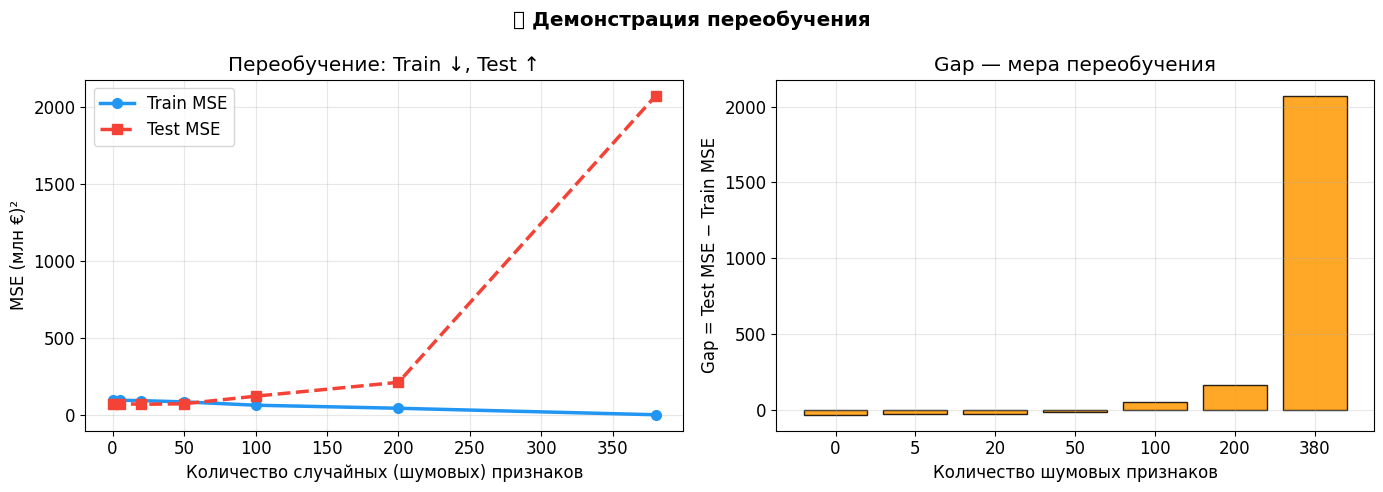

  Шума |  Train MSE |   Test MSE |        Gap
─────────────────────────────────────────────
     0 |       97.6 |       68.8 |      -28.7
     5 |       96.1 |       74.0 |      -22.1
    20 |       93.5 |       69.7 |      -23.8
    50 |       85.4 |       73.1 |      -12.2
   100 |       63.8 |      122.3 |       58.5 ← переобучение!
   200 |       44.0 |      212.5 |      168.5 ← переобучение!
   380 |        1.8 |     2074.2 |     2072.4 ← переобучение!
CHECKPOINT:overfitting_gap:{"noise_features": 380.0, "overfit_gap": 2072.432242613671}


In [9]:
noise_counts = [0, 5, 20, 50, 100, 200, 380]
train_mses, test_mses = [], []

for n_noise in noise_counts:
    if n_noise == 0:
        Xtr, Xte = X_train_b, X_test_b
    else:
        noise_tr = np.random.randn(X_train_b.shape[0], n_noise)
        noise_te = np.random.randn(X_test_b.shape[0],  n_noise)
        Xtr = np.hstack([X_train_b, noise_tr])
        Xte = np.hstack([X_test_b,  noise_te])
    try:
        w = fit_linear_regression(Xtr, y_train)
        train_mses.append(compute_mse(y_train, Xtr @ w))
        test_mses.append( compute_mse(y_test,  Xte @ w))
    except np.linalg.LinAlgError:
        train_mses.append(np.nan)
        test_mses.append(np.nan)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(noise_counts, train_mses, 'o-', color='#2196F3', lw=2.5, ms=7, label='Train MSE')
axes[0].plot(noise_counts, test_mses,  's--', color='#F44336', lw=2.5, ms=7, label='Test MSE')
axes[0].set_xlabel('Количество случайных (шумовых) признаков')
axes[0].set_ylabel('MSE (млн €)²')
axes[0].set_title('Переобучение: Train ↓, Test ↑')
axes[0].legend(fontsize=12)

gap = [te - tr for te, tr in zip(test_mses, train_mses)]
axes[1].bar(range(len(noise_counts)), gap, color='#FF9800', alpha=0.85, edgecolor='black')
axes[1].set_xticks(range(len(noise_counts)))
axes[1].set_xticklabels(noise_counts)
axes[1].set_xlabel('Количество шумовых признаков')
axes[1].set_ylabel('Gap = Test MSE − Train MSE')
axes[1].set_title('Gap — мера переобучения')

plt.suptitle('🔥 Демонстрация переобучения', fontweight='bold')
plt.tight_layout()
plt.show()

print(f"{'Шума':>6} | {'Train MSE':>10} | {'Test MSE':>10} | {'Gap':>10}")
print("─" * 45)
for n, tr, te in zip(noise_counts, train_mses, test_mses):
    flag = " ← переобучение!" if (te - tr) > 20 else ""
    print(f"{n:>6} | {tr:>10.1f} | {te:>10.1f} | {te-tr:>10.1f}{flag}")

overfit_gap = float(test_mses[-1] - train_mses[-1])
emit_checkpoint('overfitting_gap', noise_features=noise_counts[-1], overfit_gap=overfit_gap)


### 📝 TODO 2 — Анализ переобучения

Посмотри на таблицу и графики. Здесь тебе нужно проанализировать динамику ошибок и ответить ниже:

1. При каком количестве шумовых признаков начинается **заметное** переобучение?  ```На примере наших данных в диапозоне 200-380```
   Как ты это определил — по какому показателю? ```Gap между Train и Test результатами на втором графике```

2. Train MSE при 380 шумовых признаках близко к нулю.  
   Значит ли это что модель **хорошая**? Объясни почему да или нет. ```Нет, потому что модель вместо запоминания правил заучивает конкретные примеры и ответы```

3. Объясни переобучение **аналогией из жизни** (НЕ через технические термины).  
   Используй сценарий, понятный другу не из IT. ```Ученик, вместо использования новых и эффективных методик, использует самые типичные для самого себя, потому что он привык и другие не пробовал```

<details>
<summary>💡 Подсказка к аналогии</summary>

Подумай о студенте, который готовится к тесту, или о враче, который ставит диагноз  
только по одному симптому, который «однажды совпал» с нужной болезнью.
</details>


**✏️ Твои ответы:**

Ответил в прошлом абзаце



---

## 🛡️ Шаг 5: Ridge регрессия — обуздываем переобучение

### Идея: наказываем за большие веса

Мы выяснили, что переобучение происходит из-за того, что модель  
находит **огромные веса** на случайных признаках (например, +87 и −84,  
которые «отменяют» друг друга на тренировочных данных, но дают бред на новых).

**Решение Ridge:** добавить в функцию потерь штраф за большие веса:

$$\text{Loss}_{\text{Ridge}} = \underbrace{\frac{1}{n}\|\mathbf{X}\mathbf{w} - \mathbf{y}\|^2}_{\text{MSE — точность}} + \underbrace{\alpha \cdot \sum_{j=1}^{p} w_j^2}_{\text{L2 штраф — простота}}$$

Теперь модель пытается оптимизировать **два требования одновременно:**
1. 🎯 Быть точной (маленький MSE)
2. 🔒 Иметь маленькие веса (маленький штраф)

Это и есть **regularization** — регуляризация, от слова «регулярный, простой».

### Параметр $\alpha$ управляет балансом:

| $\alpha$ | Эффект |
|---------|--------|
| $\alpha = 0$ | Обычная линейная регрессия (без штрафа) |
| $\alpha = 0.01$ | Лёгкий штраф, почти не ограничивает |
| $\alpha = 1$ | Умеренная регуляризация |
| $\alpha = 100$ | Сильный штраф, веса → 0, модель «тупеет» |
| $\alpha = \infty$ | Все веса = 0, предсказание = константа |

### Аналитическое решение Ridge:

$$\mathbf{w}^*_{\text{Ridge}} = (\mathbf{X}^\top\mathbf{X} + \alpha n \cdot \mathbf{I})^{-1}\mathbf{X}^\top\mathbf{y}$$

Отличие от нормального уравнения — **только одно:** добавляем $\alpha n \cdot \mathbf{I}$ к матрице $\mathbf{X}^\top\mathbf{X}$.  
Это буквально «утяжеляет» диагональ матрицы, что:
1. Делает матрицу более **обратимой** (устойчивее к шуму)
2. «Тянет» веса **ближе к нулю**

### Почему bias НЕ регуляризируем?

Веса признаков ($w_1, ..., w_p$) контролируют **чувствительность** модели.  
Bias ($w_0$) — это просто сдвиг предсказания вверх или вниз.  
Штрафовать bias бессмысленно и даже вредно: он не участвует в переобучении,  
но если его штрафовать — модель будет систематически недооценивать стоимость.


In [ ]:
def fit_ridge(X, y, alpha=1.0):
    """
    Ridge регрессия: w* = (XᵀX + α·n·I)⁻¹ Xᵀy

    Bias-терм (индекс 0) НЕ регуляризируется!

    Args:
        X:     матрица признаков с bias (n_samples, n_features+1)
        y:     целевые значения         (n_samples,)
        alpha: сила регуляризации ≥ 0   (0 = обычная линейная)
    Returns:
        w:     вектор весов             (n_features+1,)
    """
    n, p = X.shape

    # Шаг 1: Создай матрицу регуляризации — единичная матрица p×p
    #        с НУЛЁМ на позиции [0,0] (чтобы не штрафовать bias)
    # TODO: ~2 строки
    reg_matrix = ...  # np.eye(p), потом поставь reg_matrix[0,0] = 0

    # Шаг 2: Создай модифицированную матрицу XᵀX + α·n·reg_matrix
    # TODO: ~1 строка
    XtX_reg = ...

    # Шаг 3: Реши систему (как в fit_linear_regression)
    Xty = X.T @ y
    # TODO: ~1 строка
    w = ...
    return w


<details>
<summary>💡 Подсказка 1 — структура</summary>

Ridge = нормальное уравнение + одна строка.  
Единственное добавление: к матрице `XtX` прибавляем диагональную матрицу `α·n·I`.  
`np.eye(p)` создаёт единичную матрицу размера p×p.
</details>

<details>
<summary>💡 Подсказка 2 — про reg_matrix</summary>

```python
reg_matrix = np.eye(p)
reg_matrix[0, 0] = 0   # не штрафуем bias (индекс 0)
```
</details>

<details>
<summary>💡 Подсказка 3 — полное решение</summary>

```python
reg_matrix = np.eye(p)
reg_matrix[0, 0] = 0
XtX_reg = X.T @ X + alpha * n * reg_matrix
Xty = X.T @ y
w = np.linalg.solve(XtX_reg, Xty)
```
</details>


In [ ]:
# ──── Тесты реализации Ridge ─────────────────────────────────────────────────
w_ridge_test = fit_ridge(X_train_b, y_train, alpha=1.0)
assert w_ridge_test.shape == (X_train_b.shape[1],), "Неправильная форма весов!"

# При alpha=0 Ridge должен совпадать с обычной линейной регрессией
w_ridge_0   = fit_ridge(X_train_b, y_train, alpha=0.0)
w_linear_v  = fit_linear_regression(X_train_b, y_train)
assert np.allclose(w_ridge_0, w_linear_v, atol=1e-6), \
    "При alpha=0: Ridge ДОЛЖЕН = Linear Regression!"

print("✅ Тест 1: форма весов правильная")
print("✅ Тест 2: при alpha=0 Ridge = Linear Regression")

# Как alpha влияет на L2-норму весов?
print("\nЭффект alpha на веса (норма = мера 'размера' весов):")
print(f"  {'alpha':>8} | {'||w||₂':>8} | {'Test RMSE':>10}")
print("  " + "─" * 35)
for a in [0, 0.01, 0.1, 1.0, 10.0, 100.0, 1000.0]:
    w = fit_ridge(X_train_b, y_train, alpha=a)
    norm = np.sqrt(np.sum(w[1:]**2))
    rmse = compute_rmse(y_test, X_test_b @ w)
    print(f"  {a:>8.3f} | {norm:>8.3f} | {rmse:>10.3f}")
print("  ↑ При большом alpha веса → 0, модель 'тупеет'")


---

## 🎯 Шаг 6: Кросс-валидация — честный выбор alpha

### Почему нельзя просто перебрать alpha и взять лучший по test?

Это звучит логично, но **это жульничество**.  
Если мы выбираем `alpha` по результатам на test set,  
то test set **косвенно участвует в обучении**.  
Когда придут новые данные (реальный новый игрок) — наш выбор `alpha`  
может оказаться неоптимальным именно для них.

**Аналогия:** Представь, что преподаватель показал тебе варианты экзамена  
за последние 5 лет. Ты подготовился именно к этим вопросам.  
На самом экзамене тебе дают вопросы из прошлых лет — ты отвечаешь хорошо.  
Но это не значит, что ты **понял предмет**.

### K-Fold Cross-Validation: честный подход

```
Тренировочные данные (400 игроков):

Фолд 1: [▓▓▓▓ validation] [██████████ train]  → Val MSE₁
Фолд 2: [████ train] [▓▓▓▓ val] [████ train]  → Val MSE₂
Фолд 3: [████████████ train] [▓▓▓▓ validation] → Val MSE₃
...
CV MSE = mean(Val MSE₁, Val MSE₂, Val MSE₃, ...)
```

Для каждого `alpha`:
1. Делим тренировочные данные на K частей
2. K раз: K-1 частей → обучение, 1 часть → оценка
3. Усредняем K оценок → CV MSE
4. Выбираем `alpha` с минимальным CV MSE

Только после выбора `alpha` — **один раз** оцениваем на test set.


In [ ]:
def cross_val_mse(X, y, alpha, k=5):
    """K-fold cross-validation для Ridge."""
    kf = KFold(n_splits=k, shuffle=True, random_state=42)
    val_mses = []

    for train_idx, val_idx in kf.split(X):
        X_tr, X_val = X[train_idx], X[val_idx]
        y_tr, y_val = y[train_idx], y[val_idx]

        # TODO_ID:cross_val_fold_eval:start
        w = ...
        val_pred = ...
        val_mse  = ...
        # TODO_ID:cross_val_fold_eval:end
        val_mses.append(val_mse)

    return np.mean(val_mses)

alphas  = np.logspace(-3, 3, 60)
cv_mses = [cross_val_mse(X_train_b, y_train, alpha) for alpha in alphas]
best_alpha   = alphas[np.argmin(cv_mses)]
best_cv_mse  = min(cv_mses)
print(f"Лучший alpha:    {best_alpha:.4f}")
print(f"Лучший CV MSE:   {best_cv_mse:.3f}")
emit_checkpoint('best_alpha', best_alpha=best_alpha, best_cv_mse=best_cv_mse)

plt.figure(figsize=(10, 5))
plt.semilogx(alphas, cv_mses, 'o-', color='#9C27B0', lw=2, ms=4)
plt.axvline(best_alpha, color='red', linestyle='--', lw=2, label=f'Лучший alpha = {best_alpha:.4f}')
plt.xlabel('alpha (логарифмическая шкала)')
plt.ylabel('5-fold Cross-Validation MSE')
plt.title('🎯 U-образная кривая: баланс между точностью и простотой')
plt.legend(fontsize=12)
plt.show()
print('Ожидаемая зона: best_alpha в [0.001, 1000]')


<details>
<summary>💡 Подсказка к TODO</summary>

```python
w        = fit_ridge(X_tr, y_tr, alpha=alpha)
val_pred = X_val @ w
val_mse  = compute_mse(y_val, val_pred)
```
Не забудь вызывать `fit_ridge`, а не `fit_linear_regression`!
</details>


---

## 🔪 Шаг 7: Lasso — регуляризация с отбором признаков

### Чем Lasso отличается от Ridge?

Ridge штрафует за **квадраты** весов → все веса уменьшаются, но остаются ненулевыми.  
Lasso штрафует за **модули** весов → некоторые веса становятся **ровно нулю**.

$$\text{Loss}_{\text{Ridge}} = \text{MSE} + \alpha \cdot \sum w_j^2 \quad \text{(L2)}$$

$$\text{Loss}_{\text{Lasso}} = \text{MSE} + \alpha \cdot \sum |w_j| \quad \text{(L1)}$$

**Почему L1 обнуляет веса, а L2 — нет?**  
Геометрически: Ridge ограничивает веса внутри **шара** (гладкое ограничение) —  
минимум MSE касается шара в произвольной точке, чаще не в углу.  
Lasso ограничивает веса внутри **ромба** (L1 ball) — у ромба есть **углы**  
на осях координат. Минимум с высокой вероятностью попадает именно в угол,  
где один или несколько весов = 0.

**Практический смысл Lasso:**  
«Выбор признаков автоматически» — Lasso сам решает, какие признаки оставить,  
а какие выбросить как незначимые.

**Когда Ridge, а когда Lasso?**
- Ridge: предполагаем, что **все** признаки важны (просто разной силы)
- Lasso: предполагаем, что **многие** признаки бесполезны, нужно выбрать главные
- ElasticNet: комбинация (когда не уверены)

> Lasso нельзя решить аналитически (не дифференцируема в 0) →  
> используем `sklearn.linear_model.Lasso` с итерационным алгоритмом (ISTA).


In [ ]:
from sklearn.linear_model import Lasso

# Финальные модели с лучшим alpha
w_linear_final = fit_linear_regression(X_train_b, y_train)
w_ridge_final  = fit_ridge(X_train_b, y_train, alpha=best_alpha)

lasso_model = Lasso(alpha=best_alpha, max_iter=10000)
lasso_model.fit(X_train_scaled, y_train)

# ──── Сравнение качества ─────────────────────────────────────────────────────
def eval_model(name, y_tr_pred, y_te_pred):
    tr = compute_rmse(y_train, y_tr_pred)
    te = compute_rmse(y_test,  y_te_pred)
    r2 = compute_r2(y_test,   y_te_pred)
    gap = te - tr
    return name, tr, te, r2, gap

models_results = [
    eval_model('Linear',
               X_train_b @ w_linear_final,
               X_test_b  @ w_linear_final),
    eval_model(f'Ridge (α={best_alpha:.3f})',
               X_train_b @ w_ridge_final,
               X_test_b  @ w_ridge_final),
    eval_model(f'Lasso (α={best_alpha:.3f})',
               lasso_model.predict(X_train_scaled),
               lasso_model.predict(X_test_scaled)),
]

print(f"{'Модель':30} | {'Train RMSE':>12} | {'Test RMSE':>10} | {'R²':>6} | {'Gap':>8}")
print("─" * 80)
for name, tr, te, r2, gap in models_results:
    marker = " 🥇" if name.startswith('Ridge') else ""
    print(f"{name:30} | {tr:>12.3f} | {te:>10.3f} | {r2:>6.4f} | {gap:>8.3f}{marker}")

print("\nGap = Test RMSE − Train RMSE (меньше = лучше обобщение)")


In [ ]:
# ──── Визуализация весов: что регуляризация делает с ними ────────────────────
w_lasso_full = np.concatenate([[lasso_model.intercept_], lasso_model.coef_])
labels = ['bias'] + feature_names

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

x_pos = np.arange(len(labels))
width = 0.28
axes[0].bar(x_pos - width, w_linear_final, width, label='Linear', color='#2196F3', alpha=0.85)
axes[0].bar(x_pos,         w_ridge_final,  width, label='Ridge',  color='#4CAF50', alpha=0.85)
axes[0].bar(x_pos + width, w_lasso_full,   width, label='Lasso',  color='#FF9800', alpha=0.85)
axes[0].set_xticks(x_pos); axes[0].set_xticklabels(labels, rotation=30, ha='right')
axes[0].set_ylabel('Значение веса'); axes[0].set_title('Веса: Linear vs Ridge vs Lasso')
axes[0].axhline(0, color='k', lw=0.7); axes[0].legend()

# Lasso: какие признаки обнулились?
colors_l = ['#4CAF50' if abs(w) > 0.01 else '#F44336' for w in w_lasso_full]
axes[1].barh(labels, w_lasso_full, color=colors_l, alpha=0.85)
axes[1].set_title('Lasso: 🟢 выбран, 🔴 обнулён')
axes[1].set_xlabel('Значение веса'); axes[1].axvline(0, color='k', lw=0.7)

plt.suptitle('Регуляризация: Ridge сжимает, Lasso обнуляет', fontweight='bold')
plt.tight_layout(); plt.show()

zeroed = [f for f, w in zip(feature_names, w_lasso_full[1:]) if abs(w) < 0.01]
kept   = [f for f, w in zip(feature_names, w_lasso_full[1:]) if abs(w) >= 0.01]
print(f"Lasso ОСТАВИЛ признаки: {kept}")
print(f"Lasso ОБНУЛИЛ признаки: {zeroed}")


---

## 🔬 Шаг 8: Эксперименты — «Что если...»

### TODO 3 — Learning Curves

**Вопрос:** Как качество модели зависит от **размера обучающей выборки**?  

Реализуй `learning_curve_ridge` ниже. Затем проанализируй графики и ответь:
1. При каком размере train Gap начинает стабилизироваться?
2. Что это говорит нам о достаточности данных?


In [ ]:
def learning_curve_ridge(X_tr, y_tr, X_te, y_te, alpha, sizes=None):
    if sizes is None:
        sizes = np.linspace(0.05, 1.0, 20)
    n_list, train_rmses, test_rmses = [], [], []
    for frac in sizes:
        n_take = max(10, int(frac * len(y_tr)))
        X_sub, y_sub = X_tr[:n_take], y_tr[:n_take]
        # TODO_ID:learning_curve_loop:start
        w = ...
        tr_rmse = ...
        te_rmse = ...
        # TODO_ID:learning_curve_loop:end
        n_list.append(n_take)
        train_rmses.append(tr_rmse)
        test_rmses.append(te_rmse)
    return n_list, train_rmses, test_rmses

n_list, train_rmses, test_rmses = learning_curve_ridge(X_train_b, y_train, X_test_b, y_test, alpha=best_alpha)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(n_list, train_rmses, 'o-', color='#2196F3', lw=2, label='Train RMSE')
axes[0].plot(n_list, test_rmses,  's--', color='#F44336', lw=2, label='Test RMSE')
axes[0].set_xlabel('Размер обучающей выборки'); axes[0].set_ylabel('RMSE (млн €)')
axes[0].set_title('Learning Curves: Ridge'); axes[0].legend()
gap = [te - tr for te, tr in zip(test_rmses, train_rmses)]
axes[1].fill_between(n_list, gap, alpha=0.35, color='#FF9800')
axes[1].plot(n_list, gap, 'o-', color='#FF9800', lw=2)
axes[1].set_xlabel('Размер обучающей выборки')
axes[1].set_ylabel('Gap = Test − Train RMSE')
axes[1].set_title('Generalization Gap')
plt.tight_layout(); plt.show()
emit_checkpoint('learning_curve_gap', gap_start=gap[0], gap_end=gap[-1])
print('Ожидаемая зона: gap к концу кривой обычно уменьшается')


### TODO 4 — Эксперименты на выбор

Выбери **хотя бы один** эксперимент, запусти его и создай собственный вывод по результатам.

**Эксперимент А — Экстремальный alpha:**
```python
w_huge = fit_ridge(X_train_b, y_train, alpha=1_000_000)
print(w_huge)  # Что произошло с весами?
print(f"RMSE: {compute_rmse(y_test, X_test_b @ w_huge):.3f} млн €")
# Почему RMSE ≈ std(y_test)?
```

**Эксперимент Б — Без масштабирования:**
```python
X_train_raw_b = add_bias(X_train)
X_test_raw_b  = add_bias(X_test)
w_raw = fit_ridge(X_train_raw_b, y_train, alpha=best_alpha)
# Сравни веса с w_ridge_final. В чём разница? Почему?
```

**Эксперимент В — Нелинейный признак (age²):**
```python
# Добавь (age - 26)² как новый признак
# Имитирует то, что мы знаем: пик стоимости в 26 лет
scaler2 = StandardScaler()
age_sq_tr = ((X_train[:, 0] - 26) ** 2).reshape(-1, 1)
age_sq_te = ((X_test[:, 0]  - 26) ** 2).reshape(-1, 1)
X_aug_tr = scaler2.fit_transform(np.hstack([X_train, age_sq_tr]))
X_aug_te = scaler2.transform(np.hstack([X_test,  age_sq_te]))
X_aug_tr_b = add_bias(X_aug_tr)
X_aug_te_b = add_bias(X_aug_te)
w_aug = fit_ridge(X_aug_tr_b, y_train, alpha=best_alpha)
print(f"Test RMSE с age²: {compute_rmse(y_test, X_aug_te_b @ w_aug):.3f}")
print(f"Test RMSE без age²: {compute_rmse(y_test, X_test_b @ w_ridge_final):.3f}")
```


In [ ]:
# Твой код для эксперимента:

# === Эксперимент на выбор ===
# TODO: скопируй один из экспериментов выше и запусти его



**✏️ Вывод из эксперимента (обязательно запиши!):**

Я провёл эксперимент ___. Результат: _______________  
Это объясняется тем, что: _______________


---

## ✅ Финал: Что мы построили сегодня

### Маршрут урока:

```
Данные FIFA (500 игроков, 7 признаков)
      ↓
EDA: корреляции, распределения, выбросы
      ↓
Train/Test Split (80/20) + StandardScaler (только на train!)
      ↓
Нормальное уравнение: w* = (XᵀX)⁻¹Xᵀy
      ↓
Переобучение: +300 шумовых признаков → Train MSE↓, Test MSE↑↑
      ↓
Ridge: Loss = MSE + α·Σwⱼ²  →  w* = (XᵀX + αnI)⁻¹Xᵀy
      ↓
Кросс-валидация: K-fold на train → честный выбор α
      ↓
Lasso: L1-штраф → автоматический отбор признаков
      ↓
Сравнение: Linear vs Ridge vs Lasso
```

### Ключевые числа:
- Test RMSE ≈ 3–5 млн € → точность предсказания стоимости
- R² ≈ 0.75–0.85 → модель объясняет ~80% вариации цен

### 3 вещи, которые ты теперь знаешь наизусть:
1. **Data leakage:** scaler.fit только на train, никогда на всём датасете
2. **Переобучение:** низкий train error ≠ хорошая модель, смотри на test
3. **CV:** alpha выбираем по CV на train, тест трогаем ровно один раз

---

## 🚀 Что дальше?

| Тема | Связь с сегодняшним | Где применяется |
|------|---------------------|-----------------|
| **Логистическая регрессия** | То же уравнение, другая функция потерь | Классификация: топ-клуб? |
| **Деревья решений** | Нелинейность без feature engineering | Нелинейные зависимости |
| **Нейронные сети** | Много слоёв + L2 = weight decay | GPT, DALL-E, AlphaFold |

> **Масштаб реальности:**  
> GPT-4 обучается с L2-регуляризацией (называется weight decay) на 1.8 триллионах параметров.  
> Принцип — **ровно тот же**, что ты написал сегодня в трёх строках.

### 🏠 Домашнее задание:
1. **Базовое:** Реализуй все TODO самостоятельно без подсказок (на чистом листе)
2. **Среднее:** Добавь `(age−26)²` как признак и измерь улучшение
3. **Продвинутое:** Найди реальный FIFA/Transfermarkt датасет на Kaggle и примени код
